# On the Interplay of Pre-Training, Mid-Training, and RL on Reasoning Language Models

这篇题为《On the Interplay of Pre-Training, Mid-Training, and RL on Reasoning Language Models》的论文由卡内基梅隆大学（CMU）的研究团队（Charlie Zhang, Graham Neubig, Xiang Yue）于2025年12月发表。
- 该研究在AI社区引发了广泛关注，其核心贡献在于通过一个完全可控的实验框架，**解构了大语言模型推理能力的来源，并理清了预训练、中期训练（Mid-Training）和强化学习（RL）三者之间的因果关系。**
- <font color='red'>中期训练的目的：就是构建信息更丰富的base model</font>

以下是该论文的核心内容详细介绍：

## 1. 研究背景与核心动机
近年来，以 DeepSeek-R1 和 OpenAI o1 为代表的模型通过强化学习（RL）展现了惊人的推理能力。然而，AI 社区对此陷入了一场激烈的辩论：<font color='red'>RL 究竟是真正让模型“学会”了预训练阶段未曾见过的推理能力（“点金石”），还是仅仅让模型更擅长提取预训练中已经埋藏的知识（“挖掘机”）？</font>
   - 这种分歧的根源在于，现代大模型的预训练数据（数万亿 token）是一个巨大的“黑盒”，研究者无法准确判断模型的新能力是“回忆”还是“创新”。为了从因果层面解开这一谜题，CMU 团队设计了这项研究。

## 2. 核心方法：构建“纯净的实验室”
为了摆脱真实互联网数据的干扰，研究团队并未使用现有的黑盒大模型，而是**构建了一个基于 GSM-Infinite 框架的可控合成数据“实验室”。**
- 结构与语境解耦：
  - 研究将数学推理问题拆解为“依赖图（逻辑骨架）”和“情境模板（故事背景）”。
    - 通过控制图的节点数量，可以精确控制问题的难度；
    - 通过替换情境模板，可以测试模型的跨域迁移能力。
- 过程级验证（Process-Verified Evaluation）：
  - 为了防止模型在 RL 中通过“蒙对答案”来作弊（奖励破解），研究采用了严苛的评分标准，<font color='green'>要求模型不仅最终答案正确，中间的推理步骤也必须完全正确。</font>

## 3. 四大核心发现
通过从零开始训练数百个 GPT-2 规模的模型，研究团队调和了此前的争议，得出了以下四个关键结论：
- ① RL 并非万能，**真正的能力增益取决于“能力边缘”**

RL 能否带来真正的推理能力飞跃，**极度依赖于预训练留下的“提升空间”**。
   - <font color='red'>如果 RL 针对的是预训练中已经充分掌握的简单任务，它只能起到“磨刀”的作用，让已有技能更精准，但无法突破能力边界。</font>
   - 关键突破点：
     - 只有当 RL 的数据恰好针对模型的“能力边缘”（即那些具有挑战性、略高于预训练范围，但并非完全超出理解的任务）时，RL 才能产生真正的能力增益。在这种恰到好处的难度下，模型在复杂推理任务中的成功率（pass@128）最高提升了 42%，并且这种能力还能外推（Extrapolative Generalization）到更高难度的任务中。
     
- ② ** 跨域迁移（情境泛化）** 只需极少的预训练接触
在广度上的迁移能力（Contextual Generalization）方面，<font color='green'>研究发现模型并不需要大量的预训练数据来学习新场景。</font>**只要预训练阶段有极少但充分的接触**（例如低至 1% 的长尾语境暴露），RL 就能可靠地实现跨场景的推理迁移，成功率最高提升 60%。

- ③ <font color='green'>中期训练（Mid-Training）是被严重低估的核心环节</font>
在固定的计算资源下，** <font color='green'>相比于直接使用 RL，加入“中期训练”阶段能够显著提升模型的性能。** <font color='green'>中期训练在预训练和 RL 之间起到了关键的桥梁作用</font>
  - **在固定计算量下，中期训练结合 RL 的表现比单独使用 RL 在困难任务上高出 10.8%**

    - ④ <font color='green'>过程级奖励</font> 能有效防止“奖励破解”
**在 RL 训练中，如果只根据最终答案给予奖励，模型很容易学会投机取巧（Reward Hacking）**。<font color='red'>而采用过程级奖励（即对正确的推理步骤给予奖励），能够显著减少这种现象，提高模型推理的忠实度（Reasoning Fidelity）</font>

## 总结

这篇论文通过严密的因果推断实验，为“如何培养推理模型”提供了一套精确的配方。它证明了 RL 确实能够扩展 AI 的推理边界，但前提是必须建立在预训练留有余地的基础上，且训练数据必须精准瞄准模型的“能力边缘”。同时，研究也确立了中期训练在现代大模型训练流水线中不可或缺的核心地位。

# "中期训练"具体是怎么做的、为什么它能成为预训练和RL之间的桥梁吗？这是目前落地中最具操作性的部分


结合你提到的这篇 CMU 论文以及当前大模型训练的前沿进展，中期训练（Mid-Training）确实是目前工业界落地大模型（如 Qwen、Llama 等）最核心的操作之一。
我们可以从“它具体怎么做”和“为什么它是桥梁”两个层面来深入拆解：

## 一、 中期训练具体是怎么做的？
在 CMU 的这篇论文中，研究者将大模型的训练流水线严格切分为三个阶段：

预训练（Pre-training） →→ <font color='red'>中期训练（Mid-training）</font> →→ 强化学习（RL）。

1. 数据分布的精准过渡：
- **预训练通常使用的是海量、通用的互联网语料，目的是让模型掌握基础的语言能力和常识。**
- 而中期训练使用的则是高度聚焦、质量更高、<font color='red'>与目标任务（如推理）强相关的数据（例如合成推理数据集、代码、数学题等）。</font>在 CMU 的实验中，他们**通过引入这一阶段，专门用来补充预训练在特定推理结构上的不足**。

2. 优化策略的调整：
近期的综述研究指出，中期训练不仅仅是换了一批数据，<font color='red'>它通常会引入类似“退火（annealing）”的学习率调度策略。</font>
 - **在这个阶段，模型会经历更精细的优化，以稳定收敛并提升对复杂知识的抽象能力。**

3. **计算资源的重新分配：**
CMU 的实验证明，在固定的总计算预算下，如果你把一部分原本打算用在 RL 上的算力，拿出来做中期训练，模型在域内和域外（OOD）任务上的表现都会显著增强。

## 二、<font color='red'> 为什么它能成为预训练和 RL 之间的桥梁？</font>

要理解它的“桥梁”作用，<font color='blue'> 我们需要先明确 RL 的局限性。</font>CMU 论文指出，RL 并不是无中生有的创造器，它更像是一个放大器。RL 要想发挥巨大威力，必须满足两个苛刻条件：
1. 预训练必须留有“提升空间（Headroom）”。- <font color='blue'>一定会有提升空间（sft（监督微调）在数学本质上等价于最小化前向KL散度）</font>
2. RL 的<font color='red'>训练数据</font>必须精准卡在模型的“能力边缘（Edge of competence）”。


如果预训练的基础没打好，或者模型连基本的推理原语（比如简单的逻辑推导）都没见过，直接上 RL 是无效的。此时，中期训练就发挥了决定性的桥梁作用：
1. 填补“能力鸿沟”：
预训练让模型学会了“说话”，但可能没学会“解题”。中期训练通过注入高质量的推理数据，把模型从“通用语言模型”锻造成“具备基础推理能力的模型”。它把模型的底座垫高了，为后续的 RL 提供了充足的“提升空间”。
2. 提供“泛化种子”：
- <font color='blue'>CMU 发现，如果预训练对某个新语境（比如从“动物园”换到“学校”）完全没有暴露，RL 是无法让模型突然学会迁移的。</font>
- <font color='red'>中期训练的作用就是播下种子——哪怕只给模型看 1% 的新语境数据</font>，中期训练也能让模型掌握底层的逻辑结构。有了这个种子，后续的 RL 就能极其稳健地实现跨语境的泛化。

3. 提升计算效率：
相比于单纯依赖 RL 去死磕难题，<font color='red'>中期训练能以极高的效率提升模型的基础智商</font>。
- <font color='red'>CMU 的实验显示，在固定算力下，加入中期训练比单纯做 RL 在困难任务上的表现高出 10.8%。</font>

## 总结来说：
- 如果把训练大模型比作培养一个学生，预训练是九年义务教育（学识字、学常识），
- RL 是高强度的奥数竞赛集训（突破极限），
- <font color='red'>而中期训练就是初高中的专项拔高课。</font>
  - 如果没有这门拔高课打基础，直接去上奥数集训（RL），学生要么听不懂（超出能力边缘），要么只是在重复做已经会的简单题（缺乏提升空间）。
  - <font color='red'>因此，中期训练是目前大模型从“通用”走向“高智商推理”最关键、最具操作性的落地环节。</font>

# SFT（监督微调）在数学本质上等价于最小化前向KL散度

In [1]:
from IPython.display import Image

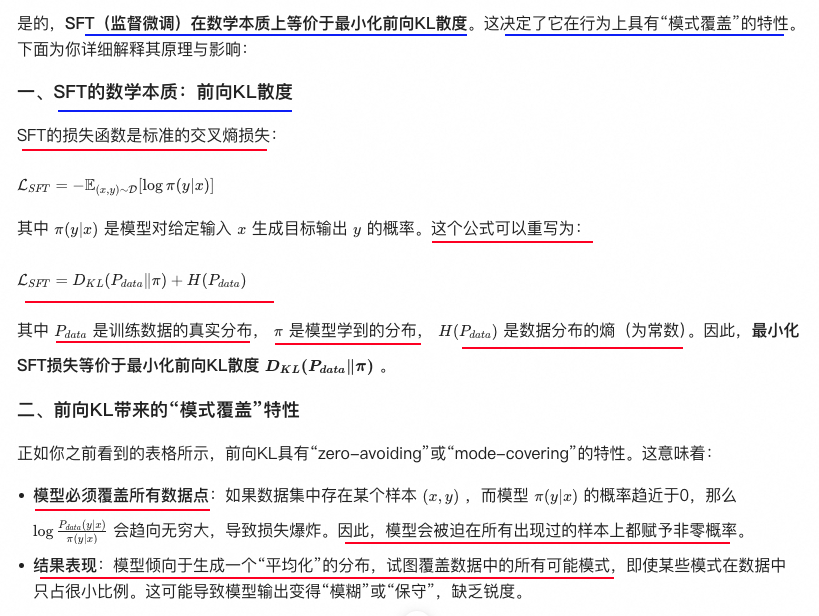

In [2]:
Image(filename='./Image/sft_kl_1.png')

## 交叉熵损失与KL散度之间的内在联系
- 简单来说，最小化交叉熵损失，在数学上就等价于最小化模型分布与真实数据分布之间的KL散度。
  - **这个转换过程其实是信息论中一个非常经典且基础的数学推导**。它揭示了交叉熵损失（Cross-Entropy Loss）与KL散度（Kullback-Leibler Divergence）之间的内在联系。


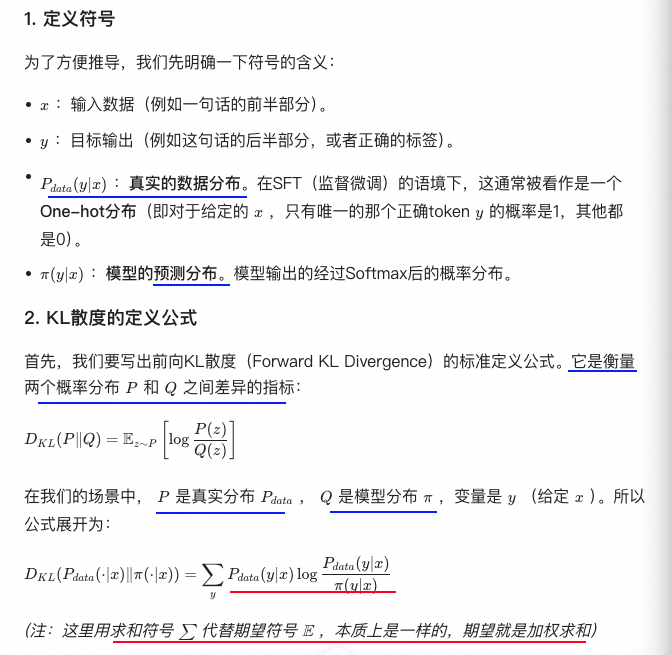

In [4]:
Image(filename='./Image/sft_c_kl1.png')

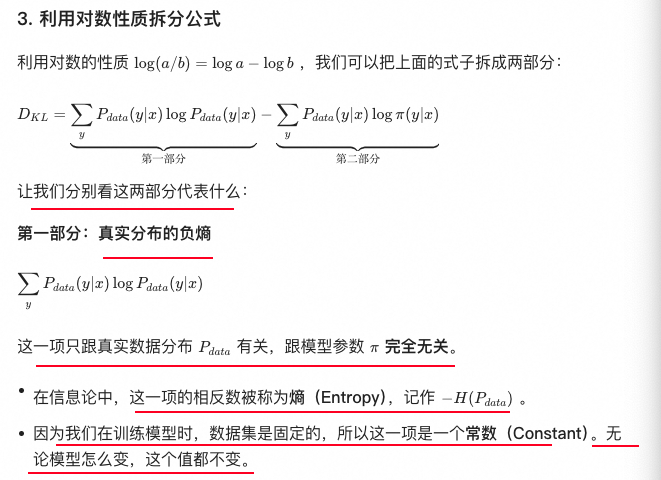

In [5]:
Image(filename='./Image/sft_c_kl2.png')

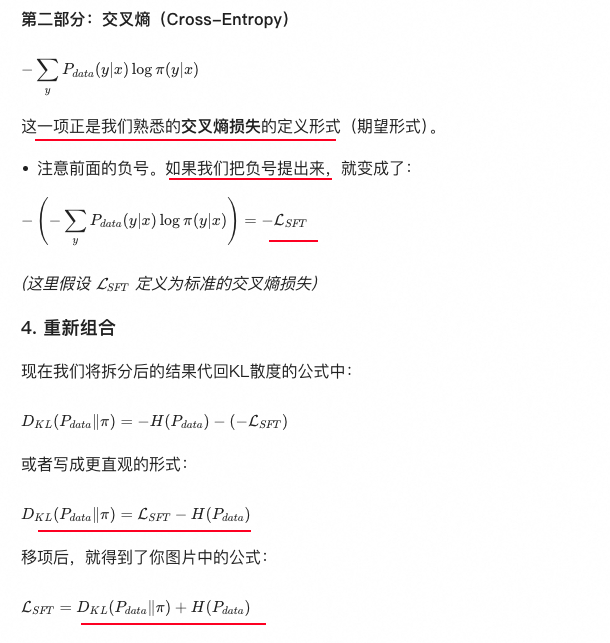

In [6]:
Image(filename='./Image/sft_c_kl3.png')

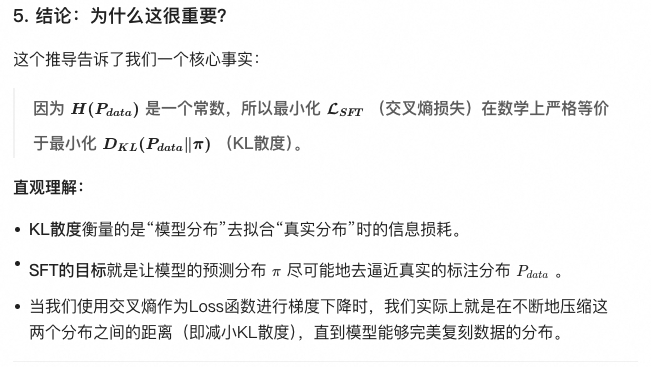

In [7]:
Image(filename='./Image/sft_c_kl4.png')

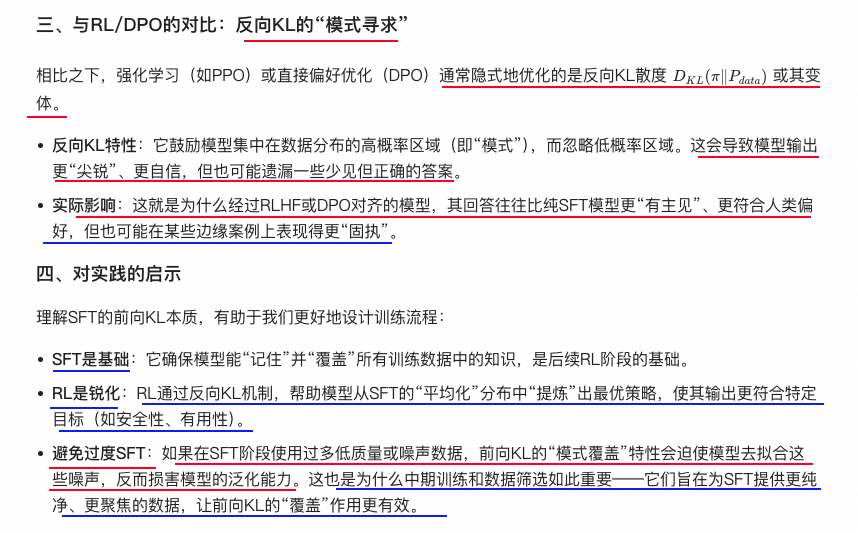

In [3]:
Image(filename='./Image/sft_kl_2.png')